<a href="https://colab.research.google.com/github/dinurisenara/test/blob/main/RoBERTaSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install and import dependancies

In [2]:
!pip install transformers datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 19.4 MB/s eta 0:00:00


Import the necessary modules

In [3]:
import torch
from transformers import RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset, Dataset
import pandas as pd


Load the Sentiment Analysis for mental health dataset

In [4]:
from google.colab import files

# Upload your kaggle.json API key
files.upload()

# Move it to the correct location
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Saving kaggle.json to kaggle.json


In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("suchintikasarkar/sentiment-analysis-for-mental-health")

print("Path to dataset files:", path)

100%|██████████| 11.1M/11.1M [00:00<00:00, 110MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/versions/1


In [6]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/versions/1"
os.listdir(dataset_path)


['Combined Data.csv']

In [7]:
import pandas as pd

# Define CSV file path (replace 'your_file.csv' with actual file name)
csv_file = f"{dataset_path}/Combined Data.csv"

# Load dataset
df = pd.read_csv(csv_file)

# Show first few rows
df.head()


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [8]:
df.info()  # Check column names and data types
df.isnull().sum()  # Check for missing values
df.columns  # List column names


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


Index(['Unnamed: 0', 'statement', 'status'], dtype='object')

In [9]:
# Remove missing values
df = df.dropna(subset=['statement'])
df = df.reset_index(drop=True)

# Verify removal
df.isnull().sum()


,0
Unnamed: 0,0
statement,0
status,0


In [10]:
df['status'].value_counts()


,count
status,
Normal,16343
Depression,15404
Suicidal,10652
Anxiety,3841
Bipolar,2777
Stress,2587
Personality disorder,1077


In [11]:
label_mapping = {
    "Anxiety": 0, "Depression": 1, "Neutral": 2, "PTSD": 3, "Bipolar": 4
}

# Apply label encoding
df['label'] = df['status'].map(label_mapping)

# Verify encoding
df[['status', 'label']].head()


,status,label
0,Anxiety,0.0
1,Anxiety,0.0
2,Anxiety,0.0
3,Anxiety,0.0
4,Anxiety,0.0


In [12]:
df['status'].value_counts()


,count
status,
Normal,16343
Depression,15404
Suicidal,10652
Anxiety,3841
Bipolar,2777
Stress,2587
Personality disorder,1077


In [13]:
df['label'].unique()


array([ 0., nan,  1.,  4.])

In [14]:
label_mapping = {
    "Anxiety": 0,
    "Depression": 1,
    "Normal": 2,
    "Suicidal": 3,
    "Bipolar": 4,
    "Stress": 5,
    "Personality disorder": 6
}

# Ensure all status values are correctly mapped
df['label'] = df['status'].map(label_mapping)

# Verify if there are still NaN values
print(df['label'].unique())


[0 2 1 3 5 4 6]


In [15]:
df = df.dropna(subset=['label'])  # Drop rows where 'label' is NaN
df['label'] = df['label'].astype(int)  # Convert labels to integer


In [16]:
print(df['label'].unique())  # Should show all integers (0-6)
print(df[['status', 'label']].head())  # Check if labels are correctly mapped


[0 2 1 3 5 4 6]
    status  label
0  Anxiety      0
1  Anxiety      0
2  Anxiety      0
3  Anxiety      0
4  Anxiety      0


In [18]:
df['label'].value_counts()


,count
label,
2,16343
1,15404
3,10652
0,3841
4,2777
5,2587
6,1077


In [21]:
df.sample(10)[['status', 'label']]


,status,label
35185,Anxiety,0
43301,Normal,2
22705,Suicidal,3
12048,Depression,1
42115,Normal,2
31191,Normal,2
38137,Depression,1
39655,Depression,1
10426,Depression,1
22729,Depression,1


In [22]:
# Convert 'status' to string (avoids mismatching issues)
df['status'] = df['status'].astype(str)

# Reapply label mapping
df['label'] = df['status'].map(label_mapping)

# Drop NaN values (if any)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)  # Ensure labels are integers

# Check again
df.sample(10)[['status', 'label']]


,status,label
13808,Depression,1
20548,Suicidal,3
33158,Normal,2
40054,Depression,1
3223,Normal,2
25038,Depression,1
39495,Depression,1
38108,Depression,1
34344,Anxiety,0
7703,Depression,1


In [23]:
from sklearn.model_selection import train_test_split

# Splitting dataset
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['statement'], df['label'], test_size=0.2, random_state=42
)

# Verify split
print(f"Training samples: {len(train_texts)}, Testing samples: {len(test_texts)}")


Training samples: 42144, Testing samples: 10537


In [24]:
from transformers import RobertaTokenizer

# Load RoBERTa tokenizer
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

# Tokenize the dataset
train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True, max_length=128)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

In [25]:
from datasets import Dataset

# Convert tokenized data to Hugging Face Dataset format
train_dataset = Dataset.from_dict({
    "input_ids": train_encodings["input_ids"],
    "attention_mask": train_encodings["attention_mask"],
    "labels": list(train_labels)
})

test_dataset = Dataset.from_dict({
    "input_ids": test_encodings["input_ids"],
    "attention_mask": test_encodings["attention_mask"],
    "labels": list(test_labels)
})


In [26]:
from transformers import RobertaForSequenceClassification

# Load pre-trained RoBERTa model with 7 output labels (for 7 emotions)
model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=7)


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [27]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./roberta_emotion_model",  # Directory to save model
    evaluation_strategy="epoch",  # Evaluate at the end of every epoch
    save_strategy="epoch",  # Save best model per epoch
    learning_rate=2e-5,  # Standard LR for transformers
    per_device_train_batch_size=16,  # Batch size (adjust if needed)
    per_device_eval_batch_size=16,  # Batch size for evaluation
    num_train_epochs=3,  # Train for 3 epochs
    weight_decay=0.01,  # Regularization to prevent overfitting
    logging_dir="./logs",  # Log directory
    logging_steps=100,  # Log every 100 steps
    load_best_model_at_end=True,  # Saves best model
    metric_for_best_model="loss",  # Tracks best model by loss
)


/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [28]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
)

# Start training
trainer.train()


<ipython-input-28-5c3e34812e0e>:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: dinurisenara425 (dinurisenara425-staffordshire-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss
1,0.446700,0.455672
2,0.360200,0.399000
3,0.290300,0.416919


TrainOutput(global_step=7902, training_loss=0.4047246316593528, metrics={'train_runtime': 3187.8313, 'train_samples_per_second': 39.661, 'train_steps_per_second': 2.479, 'total_flos': 8316787586457600.0, 'train_loss': 0.4047246316593528, 'epoch': 3.0})

In [29]:
# Save model and tokenizer
model.save_pretrained("./roberta_emotion_model")
tokenizer.save_pretrained("./roberta_emotion_model")


('./roberta_emotion_model/tokenizer_config.json',
 './roberta_emotion_model/special_tokens_map.json',
 './roberta_emotion_model/vocab.json',
 './roberta_emotion_model/merges.txt',
 './roberta_emotion_model/added_tokens.json')

In [30]:
save_path = "/content/drive/MyDrive/roberta_emotion_model"
# Save model and tokenizer to Google Drive
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"Model saved to: {save_path}")


Model saved to: /content/drive/MyDrive/roberta_emotion_model


In [31]:
import os
print(os.listdir(save_path))


['vocab.json', 'merges.txt', 'special_tokens_map.json', 'config.json', 'tokenizer_config.json', 'model.safetensors']


In [32]:
import numpy as np

# Get model predictions on the test dataset
predictions = trainer.predict(test_dataset)

# Convert logits to class labels
predicted_labels = np.argmax(predictions.predictions, axis=1)

# Extract true labels
true_labels = test_labels.to_numpy()

print("Predictions completed!")


Predictions completed!


In [33]:
from sklearn.metrics import classification_report

# Define class names
class_names = ["Anxiety", "Depression", "Normal", "Suicidal", "Bipolar", "Stress", "Personality disorder"]

# Generate classification report
report = classification_report(true_labels, predicted_labels, target_names=class_names)

print(report)


                      precision    recall  f1-score   support

             Anxiety       0.92      0.86      0.89       755
          Depression       0.79      0.77      0.78      3016
              Normal       0.96      0.96      0.96      3308
            Suicidal       0.73      0.75      0.74      2158
             Bipolar       0.83      0.89      0.86       527
              Stress       0.77      0.78      0.78       536
Personality disorder       0.67      0.81      0.73       237

            accuracy                           0.84     10537
           macro avg       0.81      0.83      0.82     10537
        weighted avg       0.84      0.84      0.84     10537



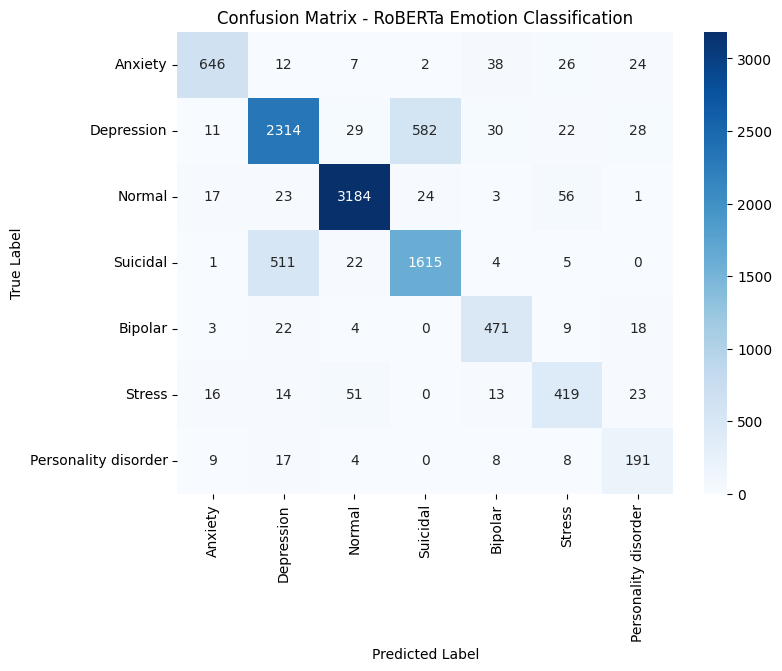

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - RoBERTa Emotion Classification")
plt.show()
